In [3]:
import pandas as pd
import geopandas as gpd
from shapely import wkt

df_bomen = pd.read_csv("data/bomen-stamgegevens.csv")

# 2. Functie om de string "SRID=28992;POINT (...)" om te zetten naar geometrie
def parse_ewkt(text):
    if pd.isna(text) or text == "":
        return None
    # Split op de puntkomma en pak het tweede deel (de pure WKT string)
    wkt_string = text.split(';')[-1]
    return wkt.loads(wkt_string)

# Pas de functie toe op de kolom "geometrie"
df_bomen['geometry_object'] = df_bomen['geometrie'].apply(parse_ewkt)

# Maak er een GeoDataFrame van
bomen = gpd.GeoDataFrame(df_bomen, geometry='geometry_object')

# Zet het coördinatensysteem (CRS) vast op RD New
bomen = bomen.set_crs(epsg=28992)

wijken = gpd.read_file("data/wijken_en_gemeenten.gpkg", layer='wijken')
if wijken.crs is None:
    wijken = wijken.set_crs(epsg=28992)

# De match maken (Spatial Join)

resultaat = gpd.sjoin(bomen, wijken, how="left", predicate="within")

print(resultaat.head())


       id    gbdBuurtId                                          geometrie  \
0  919933  3.630980e+12                SRID=28992;POINT (122115.11 483653)   
1  919934  3.630980e+12  SRID=28992;POINT (121980.147653773 483685.1651...   
2  919935  3.630980e+12             SRID=28992;POINT (118737.81 482805.51)   
3  919936  3.630980e+12  SRID=28992;POINT (122054.562595115 484656.7312...   
4  919937  3.630980e+12             SRID=28992;POINT (120154.43 483804.66)   

  boomhoogteklasseActueel    typeEigenaarPlus  jaarVanAanleg  \
0         e. 15 tot 18 m.  Gemeente Amsterdam         1948.0   
1          c. 9 tot 12 m.  Gemeente Amsterdam         1978.0   
2          c. 9 tot 12 m.  Gemeente Amsterdam         1990.0   
3           b. 6 tot 9 m.  Gemeente Amsterdam         2002.0   
4           b. 6 tot 9 m.  Gemeente Amsterdam         1985.0   

                               soortnaam          standplaats  \
0                        Tilia americana          Groenobject   
1              U

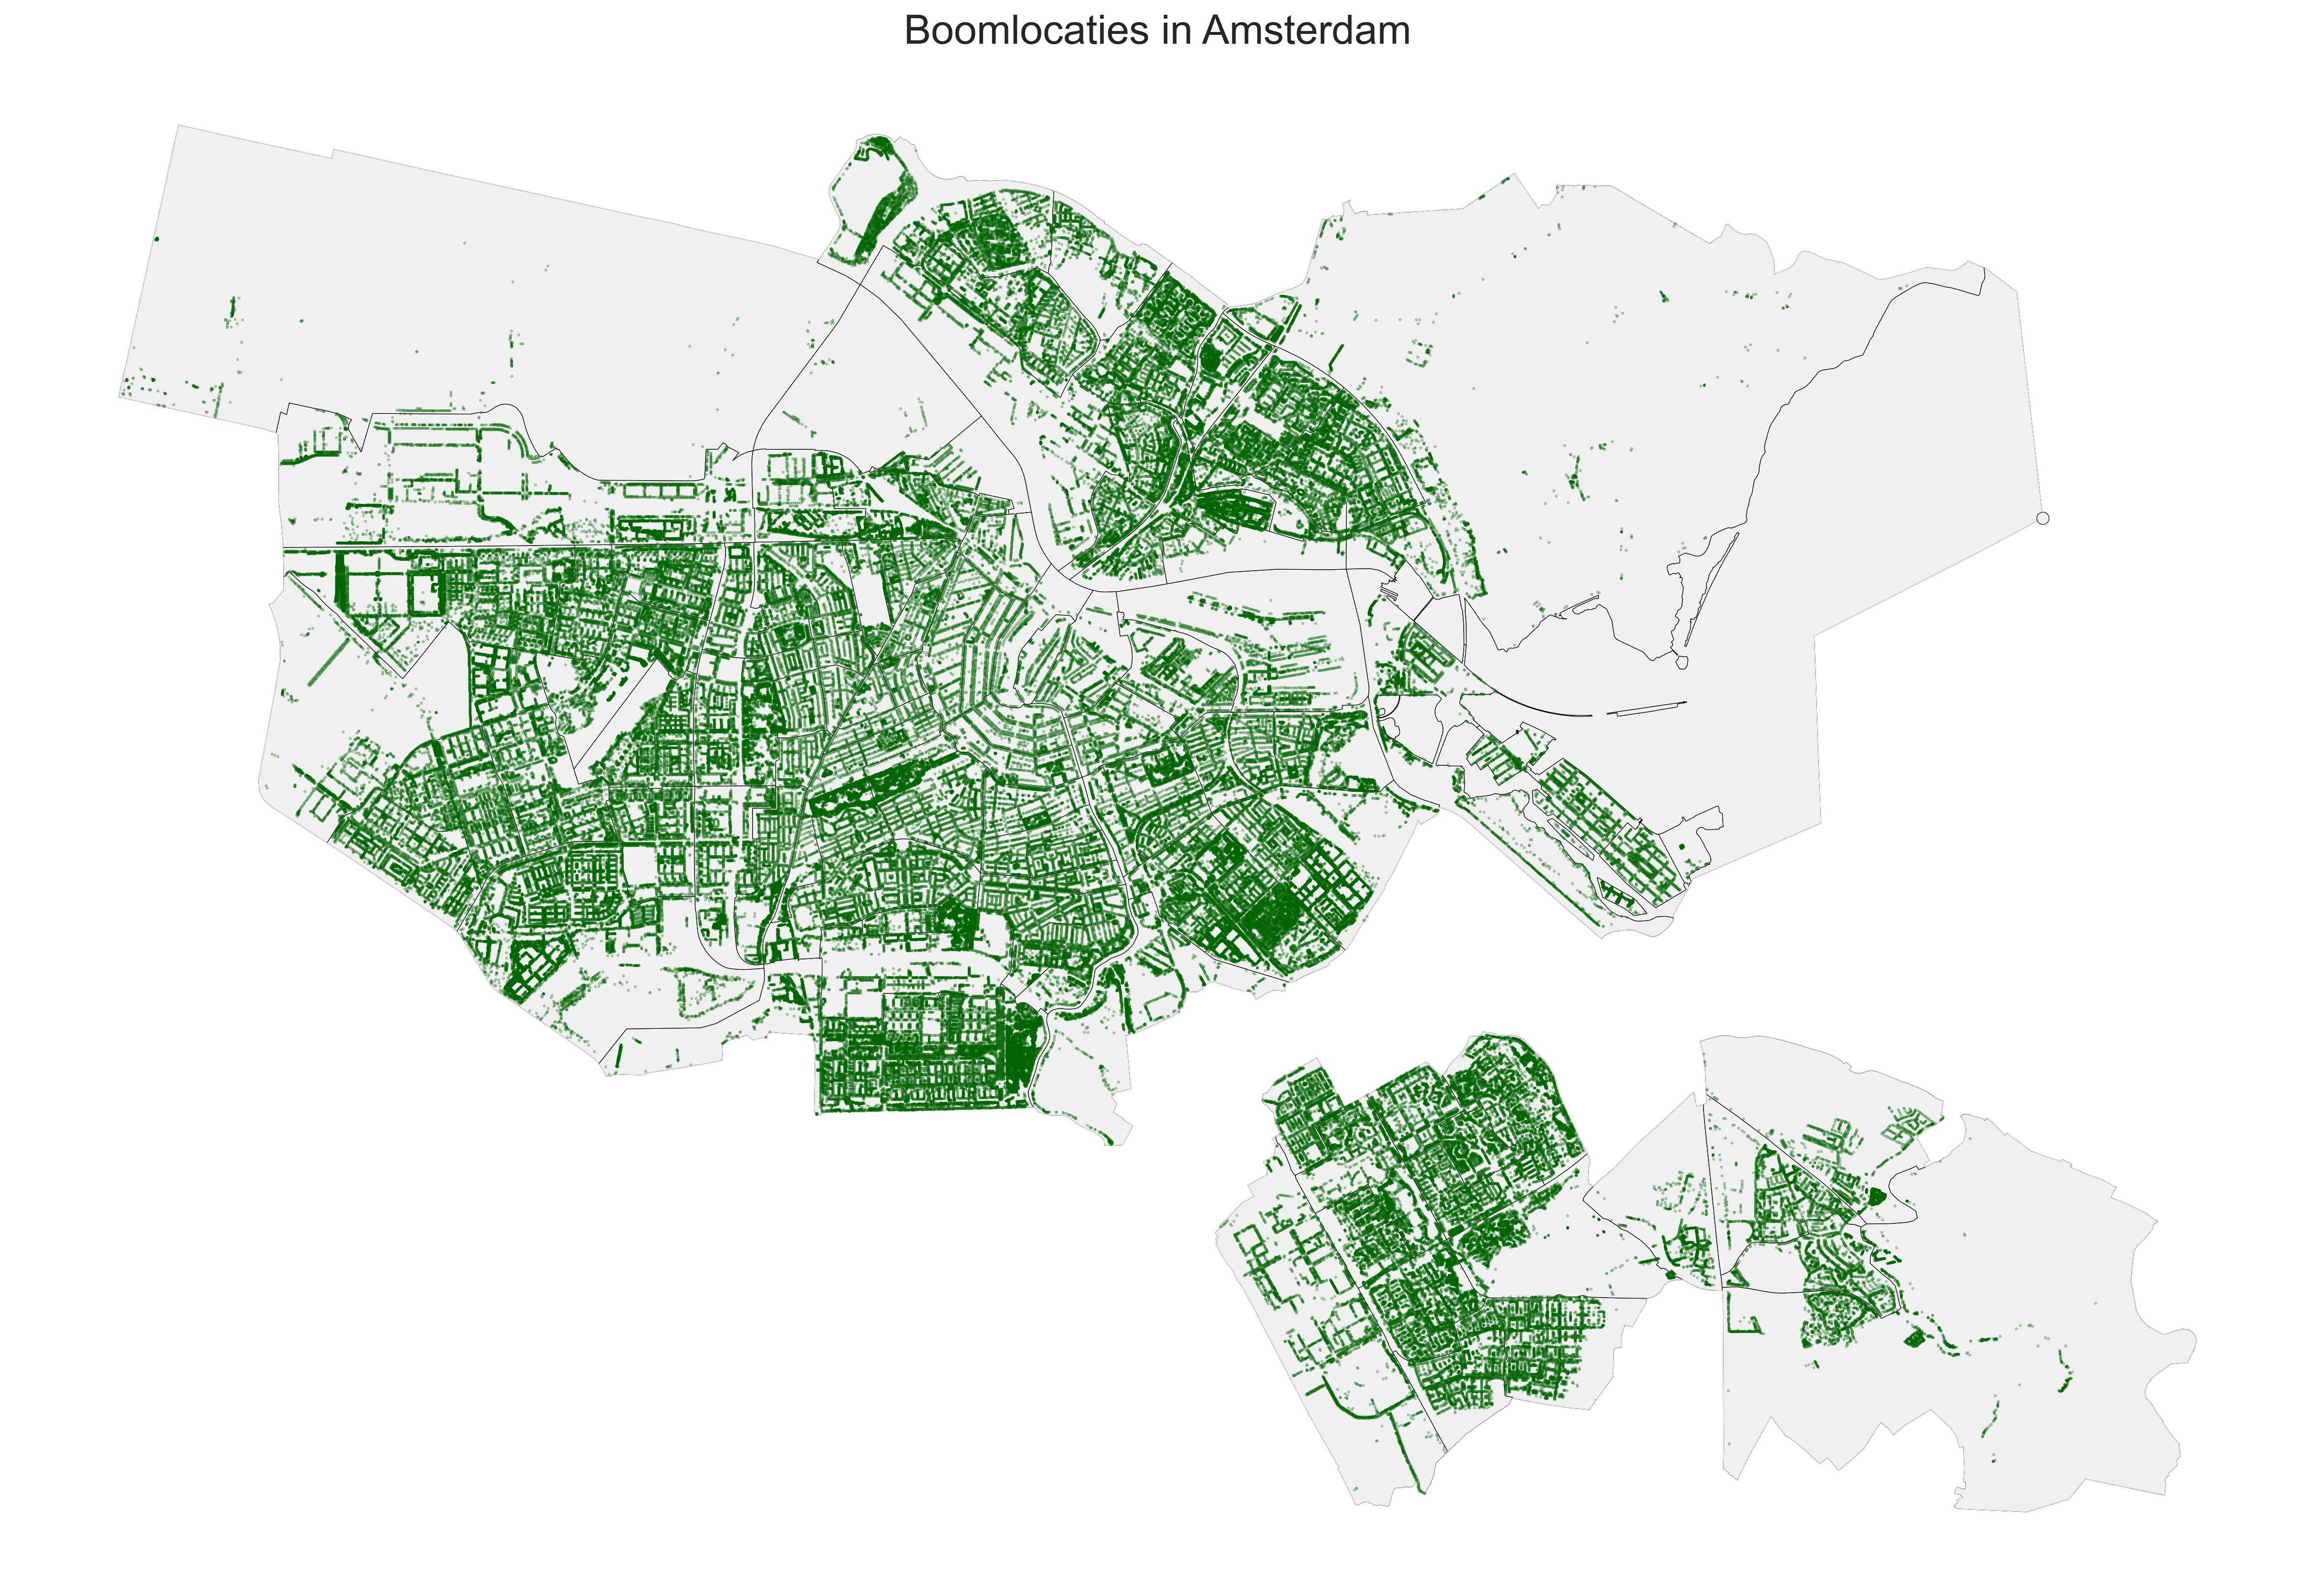

In [4]:
import matplotlib.pyplot as plt
import geopandas as gpd

gemeenten = gpd.read_file("data/wijken_en_gemeenten.gpkg", layer="gemeenten")
if gemeenten.crs is None:
    gemeenten = gemeenten.set_crs(epsg=28992)

amsterdam_grens = gemeenten[gemeenten['gemeentenaam'] == 'Amsterdam']

wijken = gpd.read_file("data/wijken_en_gemeenten.gpkg", layer="wijken")
if wijken.crs is None:
    wijken = wijken.set_crs(epsg=28992)

amsterdam_wijken = gpd.clip(wijken, amsterdam_grens)

# geen bomen buiten Adam
bomen_amsterdam = gpd.clip(resultaat, amsterdam_grens)


fig, ax = plt.subplots(figsize=(20, 20), dpi=300)

# De Wijken
amsterdam_wijken.plot(
    ax=ax,
    color='#f0f0f0',
    edgecolor='black',
    linewidth=0.3,
    zorder=1
)

# De Bomen
bomen_amsterdam.plot(
    ax=ax,
    color='darkgreen',
    markersize=0.1,
    alpha=0.5,
    zorder=2,
    label='Bomen'
)

ax.set_title("Boomlocaties in Amsterdam", fontsize=20)
ax.set_axis_off()

plt.show()